# Simple Parallel Worflow

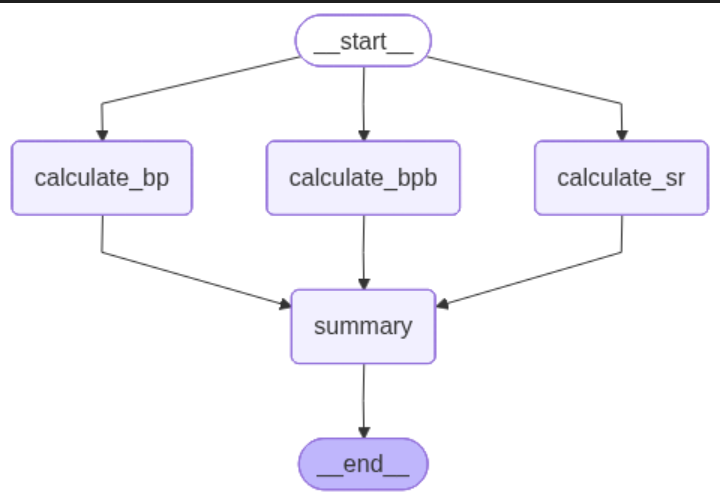

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
class BatsmanState(TypedDict):
    # input variables
    runs: int
    balls: int
    fours: int
    sixes: int

    # state variables
    strike_rate: float
    balls_per_boundary: float
    boundary_percent: float
    summary: str

In [3]:
graph = StateGraph(BatsmanState)

In [4]:
def calculate_sr(state: BatsmanState):
    sr = (state['runs']/state['balls'])*100
    return {'strike_rate': sr}

def calculate_bpb(state: BatsmanState):
    total_boundaries = state['fours'] + state['sixes'] 
    bpb = state['balls']/total_boundaries
    return {'balls_per_boundary': bpb}

def calculate_bp(state: BatsmanState):
    total_runs_from_boundary = (state['fours']*4) + (state['sixes']*6)
    bp = (total_runs_from_boundary/state['runs'])*100 
    return {'boundary_percent': bp}

def summary(state: BatsmanState):
    summary = f"""
Strike Rate: {state['strike_rate']} \n
Balls per boundary: {state['balls_per_boundary']}
Boundary Percentage: {state['boundary_percent']}
"""
    state['summary'] = summary
    return state

In [5]:
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_bp', calculate_bp)
graph.add_node('summary', summary)

Parallel Workflow

In [6]:
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_bp')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_bp', 'summary')

graph.add_edge('summary', END)


In [7]:
workflow = graph.compile()

In [8]:
initial_state = {
    'runs': 121,
    'balls': 52,
    'fours': 9,
    'sixes': 5
}

final_state = workflow.invoke(initial_state)

In [9]:
final_state

{'runs': 121,
 'balls': 52,
 'fours': 9,
 'sixes': 5,
 'strike_rate': 232.6923076923077,
 'balls_per_boundary': 3.7142857142857144,
 'boundary_percent': 54.54545454545454,
 'summary': '\nStrike Rate: 232.6923076923077 \n\nBalls per boundary: 3.7142857142857144\nBoundary Percentage: 54.54545454545454\n'}

# Parallel LLM Workflow

In [10]:
class LLMBrainstormer(TypedDict):
    problem_statement: str
    tech_solutions: str
    it_business_models: str
    social_impact_it: str
    merged_innovation_ideas: str

In [11]:
from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
)

In [12]:
def tech_solutioner(state: LLMBrainstormer):
    problem_statement = state['problem_statement']
    prompt = f"""You are an expert IT innovator and software engineer.

TASK:
Propose all possible innovative **IT solutions** for the following problem:

Problem Statement:
{problem_statement}

GUIDELINES:
- Focus on software, cloud, AI/ML, cybersecurity, networking, or IT infrastructure solutions
- Solutions should be practical, scalable, and feasible in IT
- Provide short descriptions (2–3 sentences each)
- Use bullet points for clarity

OUTPUT FORMAT:
- Solution 1: ...
- Solution 2: ...
- Solution 3: ...
...
"""
    
    
    tech_solutions = model.invoke(prompt)
    return {'tech_solutions': tech_solutions.content}

In [13]:
def businnes_model_planner(state: LLMBrainstormer):
    problem_statement = state['problem_statement']
    prompt = f"""You are a creative IT business strategist.

TASK:
Propose possible with their rank innovative **IT business models or revenue ideas** related to this problem:

Problem Statement:
{problem_statement}

GUIDELINES:
- Focus on software-as-a-service (SaaS), cloud products, apps, platforms, or IT solutions
- Ideas should be scalable, innovative, and revenue-focused
- Use bullet points for clarity
- Avoid repeating technical details

OUTPUT FORMAT:
- Model 1: ...
- Model 2: ...
- Model 3: ...
...
"""
    
    it_business_models = model.invoke(prompt)
    print(it_business_models)
    return {'it_business_models': it_business_models.content}


In [14]:
def social_impact_analyzer(state: LLMBrainstormer):
    problem_statement = state['problem_statement']
    prompt = f"""You are a social innovation expert in technology.

TASK:
Propose possible ways with their rank these IT solutions can create **positive social or environmental impact**:

Problem Statement:
{problem_statement}

GUIDELINES:
- Focus on digital inclusion, sustainability, accessibility, cybersecurity awareness, or community benefits
- Avoid repeating technical or business model details
- Use bullet points for clarity

OUTPUT FORMAT:
- Impact 1: ...
- Impact 2: ...
- Impact 3: ...
...
"""
    
    social_impact_it = model.invoke(prompt)
    return {'social_impact_it': social_impact_it.content}


In [15]:
def ideas_merger(state: LLMBrainstormer):
    tech_solutions = state['tech_solutions']
    it_business_models = state['it_business_models']
    social_impact_it = state['social_impact_it']
    prompt = f"""You are an expert IT innovation strategist.

TASK:
Merge the outputs from the following IT-focused analyses into a **single, cohesive innovation report**:

Technical Solutions:
{tech_solutions}

IT Business Models:
{it_business_models}

Social Impact:
{social_impact_it}

GUIDELINES:
- Keep all ideas clear and structured
- Label sections: Technical Solutions, IT Business Models, Social Impact in IT
- Highlight the most innovative or impactful ideas
- Avoid repeating points
- Provide a short summary (3–5 sentences) at the beginning

OUTPUT FORMAT:
IT Innovation Report:
Summary: ...
Technical Solutions:
- ...
IT Business Models:
- ...
Social Impact:
- ...
"""
    merged_innovation_ideas = model.invoke(prompt)
    state['merged_innovation_ideas'] = merged_innovation_ideas.content
    return state

In [16]:
graph = StateGraph(LLMBrainstormer)


graph.add_node('tech_solutioner', tech_solutioner)
graph.add_node('businnes_model_planner', businnes_model_planner)
graph.add_node('social_impact_analyzer', social_impact_analyzer)
graph.add_node('ideas_merger', ideas_merger)

graph.add_edge(START, 'tech_solutioner')
graph.add_edge(START, 'businnes_model_planner')
graph.add_edge(START, 'social_impact_analyzer')

graph.add_edge('tech_solutioner', 'ideas_merger')
graph.add_edge('businnes_model_planner', 'ideas_merger')
graph.add_edge('social_impact_analyzer', 'ideas_merger')

graph.add_edge('ideas_merger', END)


In [17]:
workflow = graph.compile()

In [19]:
initial_state = {'problem_statement': 'How can AI help automate document verification in banks?'}
final_state = workflow.invoke(initial_state)

content='Here are several innovative IT business models and revenue ideas leveraging AI for automated document verification in banks, ranked by their strategic innovation and potential impact:\n\n---\n\n*   **Model 1: AI Document Verification Platform (SaaS)**\n    *   **Concept:** A comprehensive, cloud-native Software-as-a-Service (SaaS) platform offering end-to-end AI-powered document ingestion, OCR, data extraction, authenticity verification, cross-referencing, and initial fraud detection for all common banking documents (IDs, proof of address, income statements, business registrations).\n    *   **Revenue Ideas:**\n        *   **Subscription Tiers:** Based on document processing volume (e.g., per 1,000 documents), number of active users, or specific feature sets (e.g., advanced fraud detection modules, premium reporting).\n        *   **Pay-Per-Use Overages:** Charging additional fees for processing volumes exceeding subscription limits.\n        *   **Managed Services:** Offering

In [22]:
final_state

{'problem_statement': 'How can AI help automate document verification in banks?',
 'tech_solutions': "Here are innovative IT solutions for automating document verification in banks using AI:\n\n*   **Intelligent OCR & NLP for Contextual Data Extraction:**\n    Utilize advanced Optical Character Recognition (OCR) combined with Natural Language Processing (NLP) to not only extract data fields but also understand the context and relationships between information on unstructured or semi-structured documents. This allows for highly accurate extraction of names, addresses, dates, and other critical data, even from varied document layouts.\n\n*   **AI-powered Cross-Document Consistency & Fraud Detection:**\n    Implement AI models that compare extracted data across multiple submitted documents (e.g., ID card, utility bill, bank statement) to identify inconsistencies or discrepancies. This system can flag potential fraud by detecting mismatched information or suspicious patterns that indicate 

In [21]:
print(final_state['tech_solutions'])

Here are innovative IT solutions for automating document verification in banks using AI:

*   **Intelligent OCR & NLP for Contextual Data Extraction:**
    Utilize advanced Optical Character Recognition (OCR) combined with Natural Language Processing (NLP) to not only extract data fields but also understand the context and relationships between information on unstructured or semi-structured documents. This allows for highly accurate extraction of names, addresses, dates, and other critical data, even from varied document layouts.

*   **AI-powered Cross-Document Consistency & Fraud Detection:**
    Implement AI models that compare extracted data across multiple submitted documents (e.g., ID card, utility bill, bank statement) to identify inconsistencies or discrepancies. This system can flag potential fraud by detecting mismatched information or suspicious patterns that indicate manipulation or identity theft.

*   **Real-time External Database Integration with AI Confidence Scoring:**

In [ ]:
print(final_state['it_business_models'])

Here are several innovative IT business models and revenue ideas leveraging AI for automated document verification in banks, ranked by their strategic innovation and potential impact:

---

*   **Model 1: AI Document Verification Platform (SaaS)**
    *   **Concept:** A comprehensive, cloud-native Software-as-a-Service (SaaS) platform offering end-to-end AI-powered document ingestion, OCR, data extraction, authenticity verification, cross-referencing, and initial fraud detection for all common banking documents (IDs, proof of address, income statements, business registrations).
    *   **Revenue Ideas:**
        *   **Subscription Tiers:** Based on document processing volume (e.g., per 1,000 documents), number of active users, or specific feature sets (e.g., advanced fraud detection modules, premium reporting).
        *   **Pay-Per-Use Overages:** Charging additional fees for processing volumes exceeding subscription limits.
        *   **Managed Services:** Offering onboarding, integ

In [ ]:
print(final_state['social_impact_it'])

Here are possible ways AI-driven document verification in banks can create positive social or environmental impact, ranked by their potential for transformative change:

*   **Impact 1: Democratized Access to Financial Services** (Digital Inclusion & Accessibility)
    *   Significantly reduces barriers to entry for individuals in remote areas, those with limited mobility, or communities historically underserved by traditional banking.
    *   Streamlines application processes, making financial products (e.g., loans, accounts) more accessible and less intimidating for people with disabilities or those with lower digital literacy.
    *   Fosters greater equity by ensuring a more consistent and unbiased verification process, reducing potential for human error or implicit bias in service provision.

*   **Impact 2: Accelerated Economic Empowerment** (Community Benefits)
    *   Speeds up the approval and disbursement of critical funds, such as small business loans, micro-financing, or em

In [25]:
print(final_state['merged_innovation_ideas'])

## IT Innovation Report: AI-Driven Document Verification for Banks

**Summary:** This report outlines a strategic vision for transforming document verification in banks through advanced AI. By leveraging cutting-edge technical solutions like Generative AI for deepfake detection and Federated Learning for collaborative fraud intelligence, financial institutions can achieve unparalleled accuracy and efficiency. This innovation enables new business models, from holistic risk assessment platforms to industry-wide fraud networks, while simultaneously driving significant positive social impact through democratized financial access, accelerated economic empowerment, and a reduced environmental footprint.

---

### Technical Solutions

Innovative AI-driven solutions are poised to revolutionize document verification, enhancing security, efficiency, and customer experience.

*   **Intelligent OCR & NLP for Contextual Data Extraction:** Advanced AI to accurately extract and understand contextual 